# 03 — Algorithm selection, tuning, and clustering

`src/train.py` fits a mean baseline and four regressors (linear, ridge, gradient boosting, random forest), plus a majority baseline and three classifiers, using RandomizedSearchCV. The shipped choice, recorded in `reports/regression_results.csv` and `reports/classification_results.csv`, is linear regression and logistic regression: on this nearly linear table they match or beat the trees.

K-Means is swept for k = 2…8 in `reports/clustering_metrics.csv`. Silhouette barely moves. The app uses k = 4 because the four habit names are usable, not because the clusters are sharp.


Regression
            Model  CV_RMSE      MAE    MedAE     RMSE        R2    Adj_R2  Typ_RMSE    Typ_R2                                                                                                       Best_Params
Linear Regression 0.956695 0.857879 0.544488 2.531539  0.626467  0.621597  0.813664  0.940734                                                                                                                {}
            Ridge 0.956695 0.857880 0.544501 2.531541  0.626467  0.621597  0.813667  0.940734                                                                                            {'model__alpha': 0.01}
Gradient Boosting 1.025457 0.927928 0.598861 2.555922  0.619237  0.614273  0.897784  0.927847         {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1}
    Random Forest 1.277055 1.123185 0.763333 2.648267  0.591226  0.585897  1.166194  0.878255 {'model__n_estimators': 300, 'model__min_samples_split': 2, 'mo

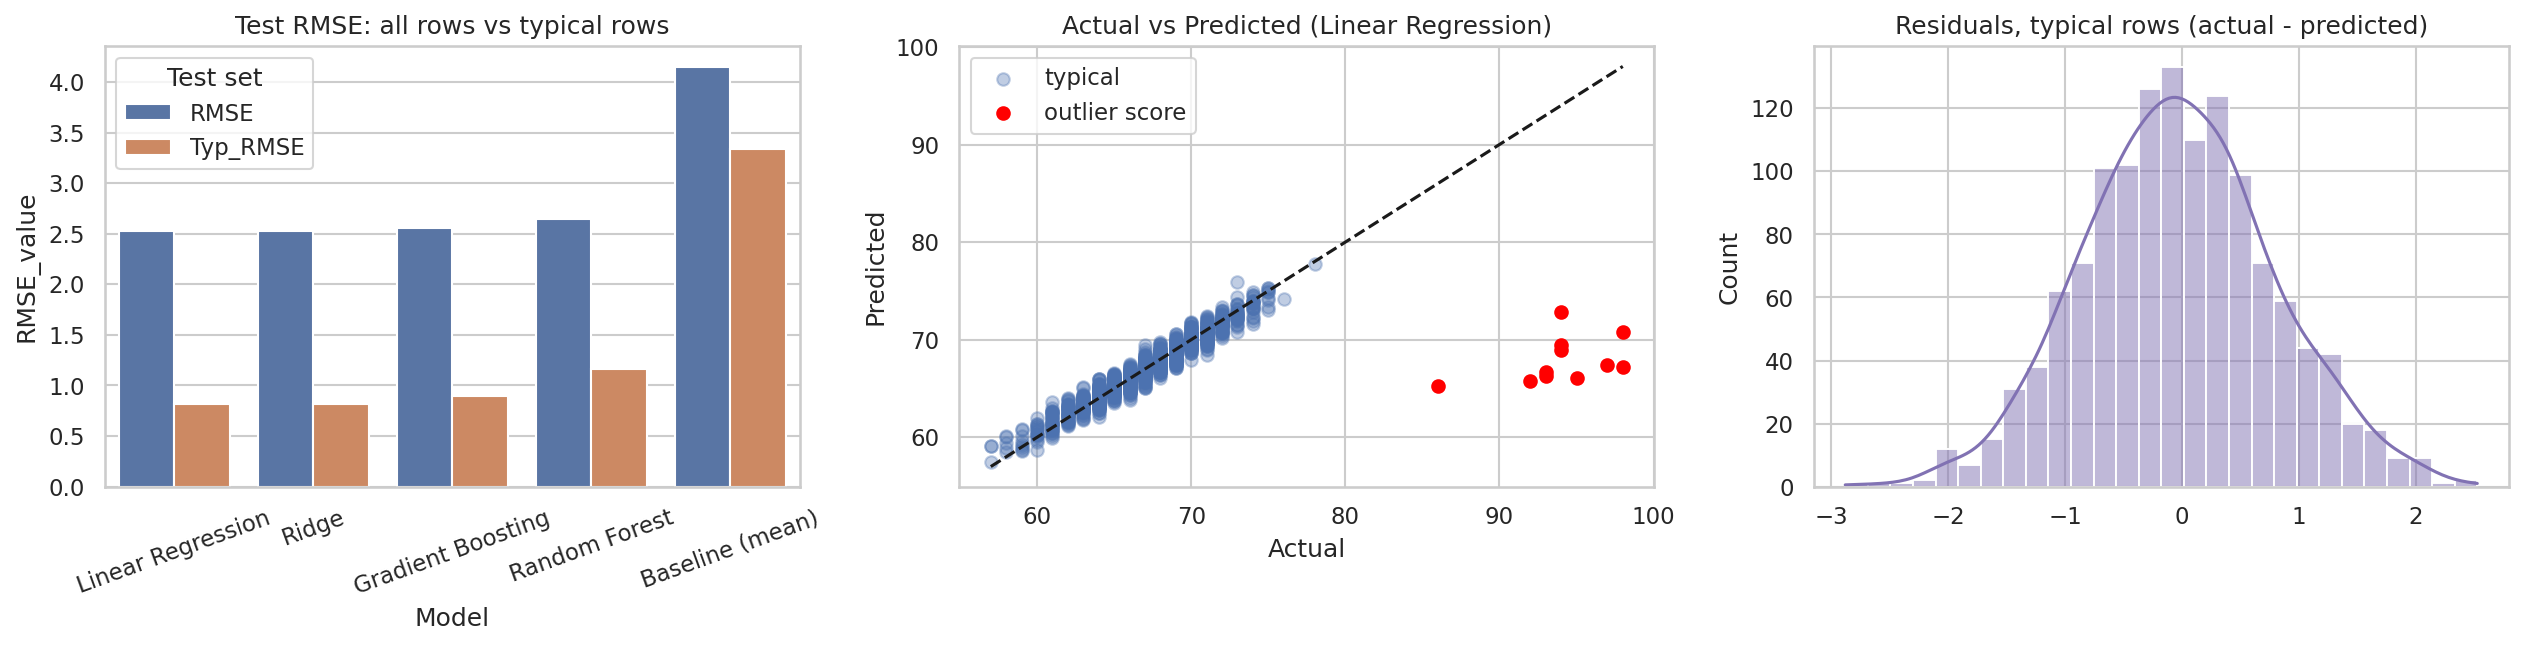

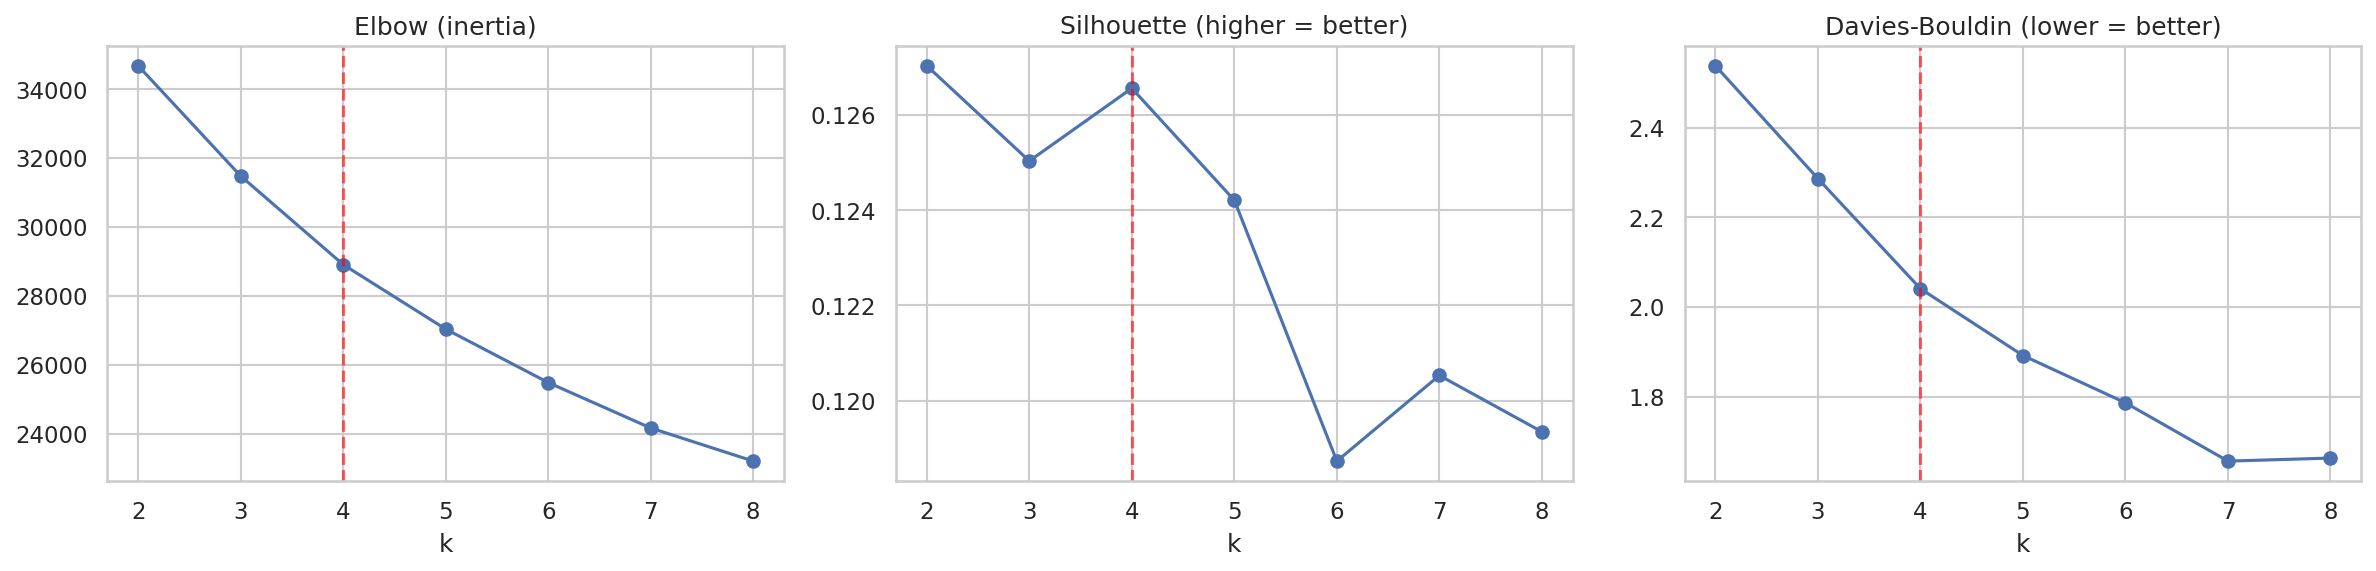

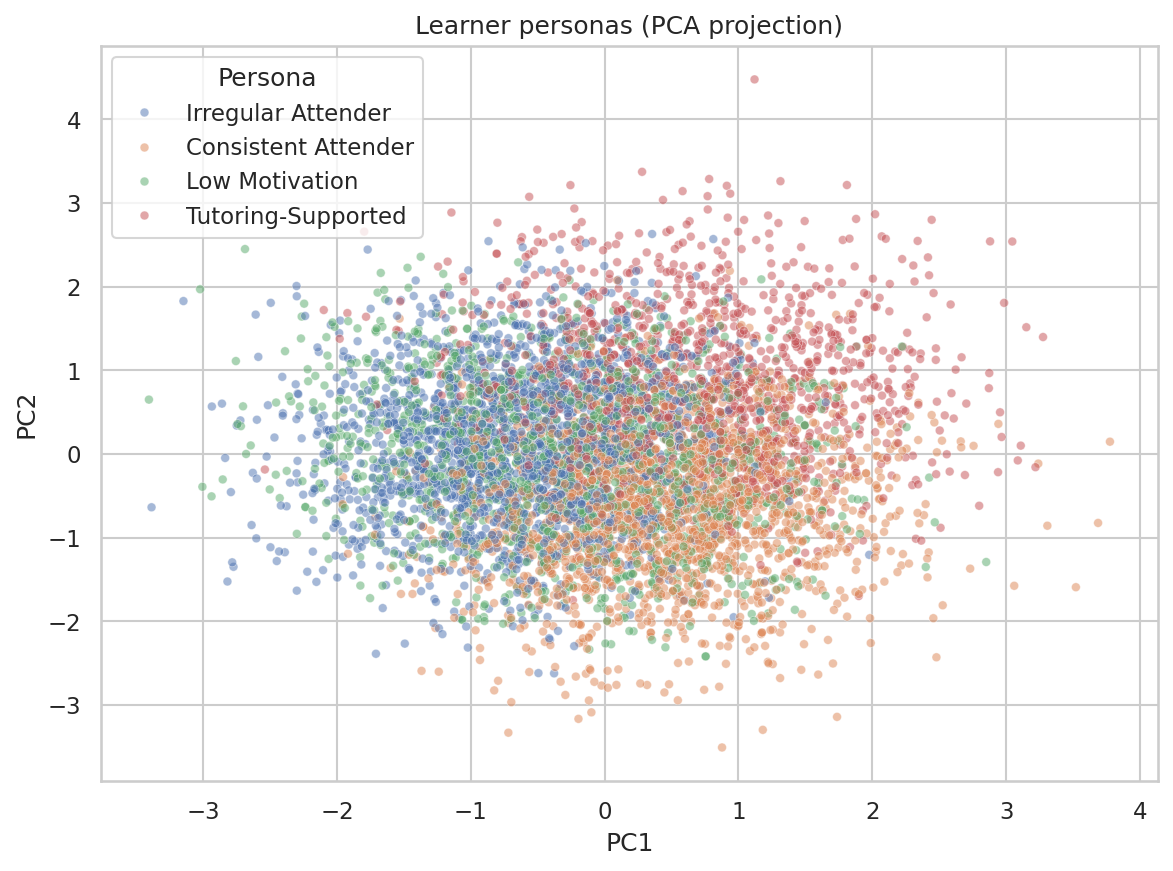

In [1]:
import pandas as pd
from IPython.display import Image, display
from pathlib import Path

print("Regression")
print(pd.read_csv("reports/regression_results.csv").to_string(index=False))
print("\nClassification")
print(pd.read_csv("reports/classification_results.csv").to_string(index=False))
print("\nClustering")
print(pd.read_csv("reports/clustering_metrics.csv").to_string(index=False))
for name in ["regression_results.png", "clustering_k_selection.png", "clustering_personas.png"]:
    display(Image(filename=str(Path("reports/figures") / name)))


## Tuning

`reports/tuning_impact.csv` and `reports/overfitting_check.csv` are written by the same `src/train.py` process (the tuning section runs after the search). Linear regression has no hyperparameters. Tree models are searched; on this data the extra capacity does not beat the linear test error.


In [2]:
from pathlib import Path
import pandas as pd
for name in ["tuning_impact.csv", "overfitting_check.csv"]:
    path = Path("reports") / name
    print(path.as_posix(), "exists" if path.exists() else "missing — run python -m src.train")
    if path.exists():
        print(pd.read_csv(path).to_string(index=False))


reports/tuning_impact.csv exists
              Model  CV_RMSE  test_RMSE  train_RMSE  overfit_gap                                                                                                       Best_Params    CV_F1  test_F1  train_F1
  Linear Regression 0.906992   1.896422    0.911144     0.985278                                                                                                                {}      NaN      NaN       NaN
              Ridge 0.906992   1.896420    0.911144     0.985277                                                                                            {'model__alpha': 0.01}      NaN      NaN       NaN
  Gradient Boosting 0.983595   1.928567    0.906392     1.022175         {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 2, 'model__learning_rate': 0.1}      NaN      NaN       NaN
      Random Forest 1.243668   2.066416    0.561551     1.504864 {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_sa